In [1]:
#Changing the working directory to the root
%cd ../..

/home/michaelajao/hospitalization_research


In [2]:
import pandas as pd
import numpy as np
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import plotly.express as px
from tqdm.notebook import tqdm
import plotly.io as pio
pio.templates.default = "plotly_white"
import os
from scipy.stats import spearmanr
import seaborn as sns
import requests
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm
source_data = Path("data/")
np.random.seed()
tqdm.pandas()

In [3]:
data = pd.read_csv(source_data/'NHS_region/filtered_data.csv')
data.head()

,areaCode,areaName,areaType,date,covidOccupiedMVBeds,cumAdmissions,hospitalCases,newAdmissions
0,E40000007,East of England,nhsRegion,2023-05-31,5.0,105345,262.0,40
1,E40000007,East of England,nhsRegion,2023-05-30,3.0,105305,252.0,40
2,E40000007,East of England,nhsRegion,2023-05-29,4.0,105265,258.0,51
3,E40000007,East of England,nhsRegion,2023-05-28,6.0,105214,261.0,32
4,E40000007,East of England,nhsRegion,2023-05-27,8.0,105182,263.0,27


In [4]:
# Function to convert relevant columns to numerical format (including population)
def convert_columns_to_numerical(df, columns_to_convert):
    # Converting columns by replacing commas and converting to integers
    for column in columns_to_convert:
        df[column] = df[column].replace(',', '', regex=True).astype(int)

    return df

In [5]:
data = convert_columns_to_numerical(data, ["covidOccupiedMVBeds", "cumAdmissions", "hospitalCases", "newAdmissions"])
data.head()

,areaCode,areaName,areaType,date,covidOccupiedMVBeds,cumAdmissions,hospitalCases,newAdmissions
0,E40000007,East of England,nhsRegion,2023-05-31,5,105345,262,40
1,E40000007,East of England,nhsRegion,2023-05-30,3,105305,252,40
2,E40000007,East of England,nhsRegion,2023-05-29,4,105265,258,51
3,E40000007,East of England,nhsRegion,2023-05-28,6,105214,261,32
4,E40000007,East of England,nhsRegion,2023-05-27,8,105182,263,27


In [6]:
data_lon = data.loc[data.areaName == "London", ["date", "covidOccupiedMVBeds", "cumAdmissions", "hospitalCases", "newAdmissions"]]
data_lon.head()

,date,covidOccupiedMVBeds,cumAdmissions,hospitalCases,newAdmissions
5775,2023-05-31,37,158366,591,44
5776,2023-05-30,35,158322,594,44
5777,2023-05-29,33,158278,574,37
5778,2023-05-28,36,158241,566,39
5779,2023-05-27,34,158202,601,26


In [7]:
columns1 = ["cumAdmissions", "hospitalCases", "newAdmissions", "covidOccupiedMVBeds"]
predictor_variables1 = data_lon[columns1]

In [8]:
# Compute the 7-day moving average for trend
for predictor in predictor_variables1:
    data_lon[f'{predictor}_trend'] = data_lon[predictor].rolling(window=7).mean()
    data_lon.dropna(inplace=True)
    
data.head()

,areaCode,areaName,areaType,date,covidOccupiedMVBeds,cumAdmissions,hospitalCases,newAdmissions
0,E40000007,East of England,nhsRegion,2023-05-31,5,105345,262,40
1,E40000007,East of England,nhsRegion,2023-05-30,3,105305,252,40
2,E40000007,East of England,nhsRegion,2023-05-29,4,105265,258,51
3,E40000007,East of England,nhsRegion,2023-05-28,6,105214,261,32
4,E40000007,East of England,nhsRegion,2023-05-27,8,105182,263,27


In [9]:
data_lon.tail()

,date,covidOccupiedMVBeds,cumAdmissions,hospitalCases,newAdmissions,cumAdmissions_trend,hospitalCases_trend,newAdmissions_trend,covidOccupiedMVBeds_trend
6925,2020-04-06,914,11341,5058,743,13230.285714,5070.142857,595.428571,958.142857
6926,2020-04-05,800,10598,4869,732,12634.857143,5061.285714,645.142857,924.571429
6927,2020-04-04,824,9866,4691,733,11989.714286,5030.000000,679.857143,894.428571
6928,2020-04-03,759,9133,4092,647,11309.857143,4876.285714,696.428571,851.857143
6929,2020-04-02,673,8486,4168,835,10613.428571,4728.714286,736.571429,826.714286


In [10]:
# Convert the date column to a datetime object
data_lon['date'] = pd.to_datetime(data_lon['date'])
ts_df = data.copy()

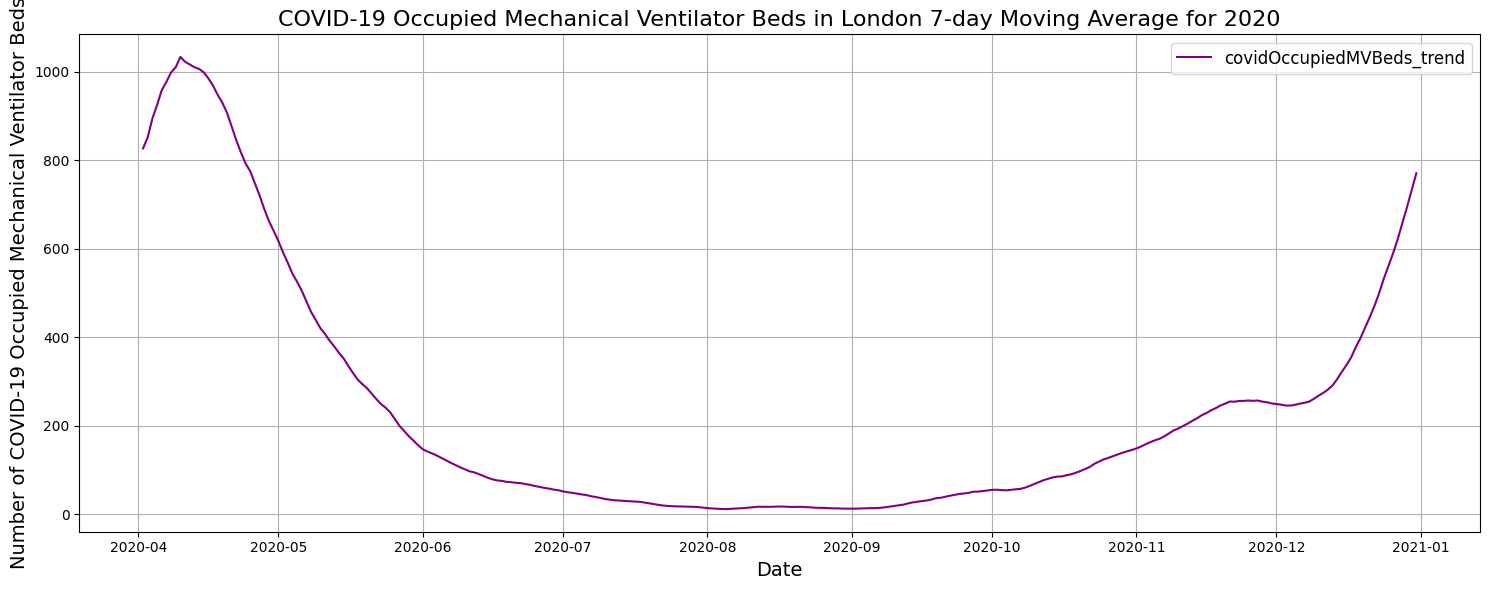

In [11]:
data_lon_2020 = data_lon[data_lon['date'].dt.year == 2020]

# Plotting the Vax index
plt.figure(figsize=(15, 6))
plt.plot(data_lon_2020['date'], data_lon_2020['covidOccupiedMVBeds_trend'], color='purple', label='covidOccupiedMVBeds_trend')
plt.title('COVID-19 Occupied Mechanical Ventilator Beds in London 7-day Moving Average for 2020', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of COVID-19 Occupied Mechanical Ventilator Beds', fontsize=14)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('images/Lon_covidOccupiedMVBeds_trend_2020.png')
plt.show()

In [12]:
columns2 = ["cumAdmissions_trend", "hospitalCases_trend", "newAdmissions_trend"]
predictor_variables2 = data_lon[columns2]

In [13]:
# Create lagged variables for the range 7 to 10
for lag in range(5, 11):
    for predictor in predictor_variables2:
        data_lon[f'{predictor}_lag{lag}'] = data_lon[predictor].shift(lag)

In [14]:
# Calculate the correlation for each lagged variable with the dependent variable
correlations = {}
for predictor in predictor_variables2:
    for lag in range(5, 11):
        correlations[f'{predictor}_lag{lag}'] = data_lon[f'{predictor}_lag{lag}'].corr(data_lon['covidOccupiedMVBeds_trend'])

# Find the lag with the highest correlation for each predictor
optimal_lags = {predictor: max((v, k) for k, v in correlations.items() if predictor in k)[1] for predictor in predictor_variables2}
optimal_lags


{'cumAdmissions_trend': 'cumAdmissions_trend_lag10',
 'hospitalCases_trend': 'hospitalCases_trend_lag5',
 'newAdmissions_trend': 'newAdmissions_trend_lag5'}

In [15]:
ts_df.head()

,areaCode,areaName,areaType,date,covidOccupiedMVBeds,cumAdmissions,hospitalCases,newAdmissions
0,E40000007,East of England,nhsRegion,2023-05-31,5,105345,262,40
1,E40000007,East of England,nhsRegion,2023-05-30,3,105305,252,40
2,E40000007,East of England,nhsRegion,2023-05-29,4,105265,258,51
3,E40000007,East of England,nhsRegion,2023-05-28,6,105214,261,32
4,E40000007,East of England,nhsRegion,2023-05-27,8,105182,263,27


In [16]:
for predictor in predictor_variables1:
    # Compute the 7-day moving average for trend
    trend = ts_df[predictor].rolling(window=7).mean()

    # Seasonal decomposition for additive model
    additive_result = seasonal_decompose(ts_df[predictor], model='additive', period=7)
    
    # Regress original variable on trend
    X_trend = sm.add_constant(trend.dropna())  # Add a constant (intercept)
    y_original = ts_df[predictor].loc[X_trend.index]
    model_trend = sm.OLS(y_original, X_trend).fit()
    r2_trend = model_trend.rsquared

    # Regress original variable on trend adjusted by additive seasonal
    X_trend_seasonal = sm.add_constant((trend + additive_result.seasonal).dropna())  # Change to multiplication for multiplicative model
    y_original_seasonal = ts_df[predictor].loc[X_trend_seasonal.index]
    model_trend_seasonal = sm.OLS(y_original_seasonal, X_trend_seasonal).fit()
    r2_trend_seasonal = model_trend_seasonal.rsquared

    # Compare R-squared
    gain = r2_trend_seasonal - r2_trend
    print(f"For predictor {predictor}, gain in R-squared by considering seasonal component: {gain}")

For predictor cumAdmissions, gain in R-squared by considering seasonal component: 2.0261907430541015e-05
For predictor hospitalCases, gain in R-squared by considering seasonal component: 0.0001673280292482371
For predictor newAdmissions, gain in R-squared by considering seasonal component: 0.005692182124344858
For predictor covidOccupiedMVBeds, gain in R-squared by considering seasonal component: 4.164912932314024e-06


In [17]:
# List of predictor variables for which you want to calculate the moving average
predictor_variables1 = ['covidOccupiedMVBeds', 'cumAdmissions', 'hospitalCases', 'newAdmissions']

# List of unique area names
area_names = ['East of England', 'North East and Yorkshire', 'South East', 'North West', 'Midlands', 'London', 'South West']

# List to store the DataFrames for each area
data_frames = []

# Iterate through the area names
for area_name in area_names:
    # Filter data for the current area name
    data_area = data[data['areaName'] == area_name].copy()
    
    # Compute the 7-day moving average for each predictor
    for predictor in predictor_variables1:
        data_area[f'{predictor}_trend'] = data_area[predictor].rolling(window=7).mean()

    # Add the data for the current area name to the list of DataFrames
    data_frames.append(data_area)

# Concatenate all the DataFrames together
final_data = pd.concat(data_frames)

# Drop rows with NA values (from the rolling window calculation)
final_data.dropna(inplace=True)

# Display the head of the final DataFrame
final_data.head()


,areaCode,areaName,areaType,date,covidOccupiedMVBeds,cumAdmissions,hospitalCases,newAdmissions,covidOccupiedMVBeds_trend,cumAdmissions_trend,hospitalCases_trend,newAdmissions_trend
6,E40000007,East of England,nhsRegion,2023-05-25,6,105123,286,35,5.571429,105227.000000,264.857143,36.714286
7,E40000007,East of England,nhsRegion,2023-05-24,7,105088,318,44,5.857143,105190.285714,272.857143,37.285714
8,E40000007,East of England,nhsRegion,2023-05-23,7,105044,313,43,6.428571,105153.000000,281.571429,37.714286
9,E40000007,East of England,nhsRegion,2023-05-22,9,105001,335,60,7.142857,105115.285714,292.571429,39.000000
10,E40000007,East of England,nhsRegion,2023-05-21,7,104941,337,41,7.285714,105076.285714,303.428571,40.285714


In [18]:
# Convert the date column to a datetime object
final_data['date'] = pd.to_datetime(final_data['date'])
final_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8043 entries, 6 to 8084
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   areaCode                   8043 non-null   object        
 1   areaName                   8043 non-null   object        
 2   areaType                   8043 non-null   object        
 3   date                       8043 non-null   datetime64[ns]
 4   covidOccupiedMVBeds        8043 non-null   int64         
 5   cumAdmissions              8043 non-null   int64         
 6   hospitalCases              8043 non-null   int64         
 7   newAdmissions              8043 non-null   int64         
 8   covidOccupiedMVBeds_trend  8043 non-null   float64       
 9   cumAdmissions_trend        8043 non-null   float64       
 10  hospitalCases_trend        8043 non-null   float64       
 11  newAdmissions_trend        8043 non-null   float64       
dtypes: datetime

In [19]:
columns=['covidOccupiedMVBeds', 'cumAdmissions', 'hospitalCases', 'newAdmissions']
# final_data = final_data.drop(columns, axis=1)

### Differencing on target variable


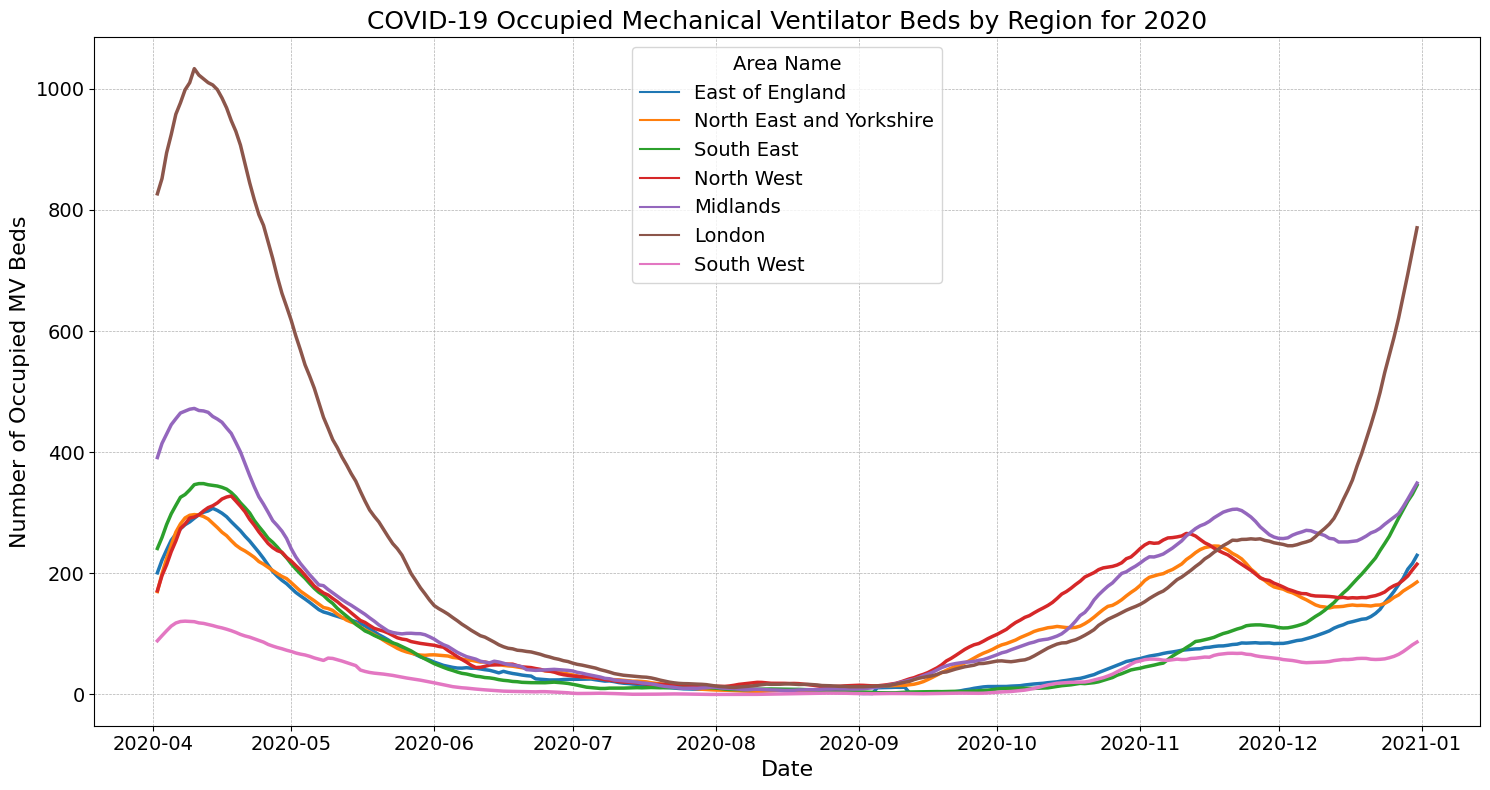

In [39]:

final_data_2020 = final_data[final_data['date'].dt.year == 2020]

# Plotting
plt.figure(figsize=[15, 8])
sns.lineplot(data=final_data_2020, x='date', y='covidOccupiedMVBeds_trend', hue='areaName', palette='tab10', linewidth=2.5)
plt.title('COVID-19 Occupied Mechanical Ventilator Beds by Region for 2020', fontsize=18)
plt.xlabel('Date', fontsize=16)
plt.ylabel('Number of Occupied MV Beds', fontsize=16)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(title='Area Name', fontsize=14, title_fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Save the plot with high resolution
plt.tight_layout()
plt.savefig('images/covidOccupiedMVBeds_trend_2020.png', format='png', dpi=300)
plt.show()

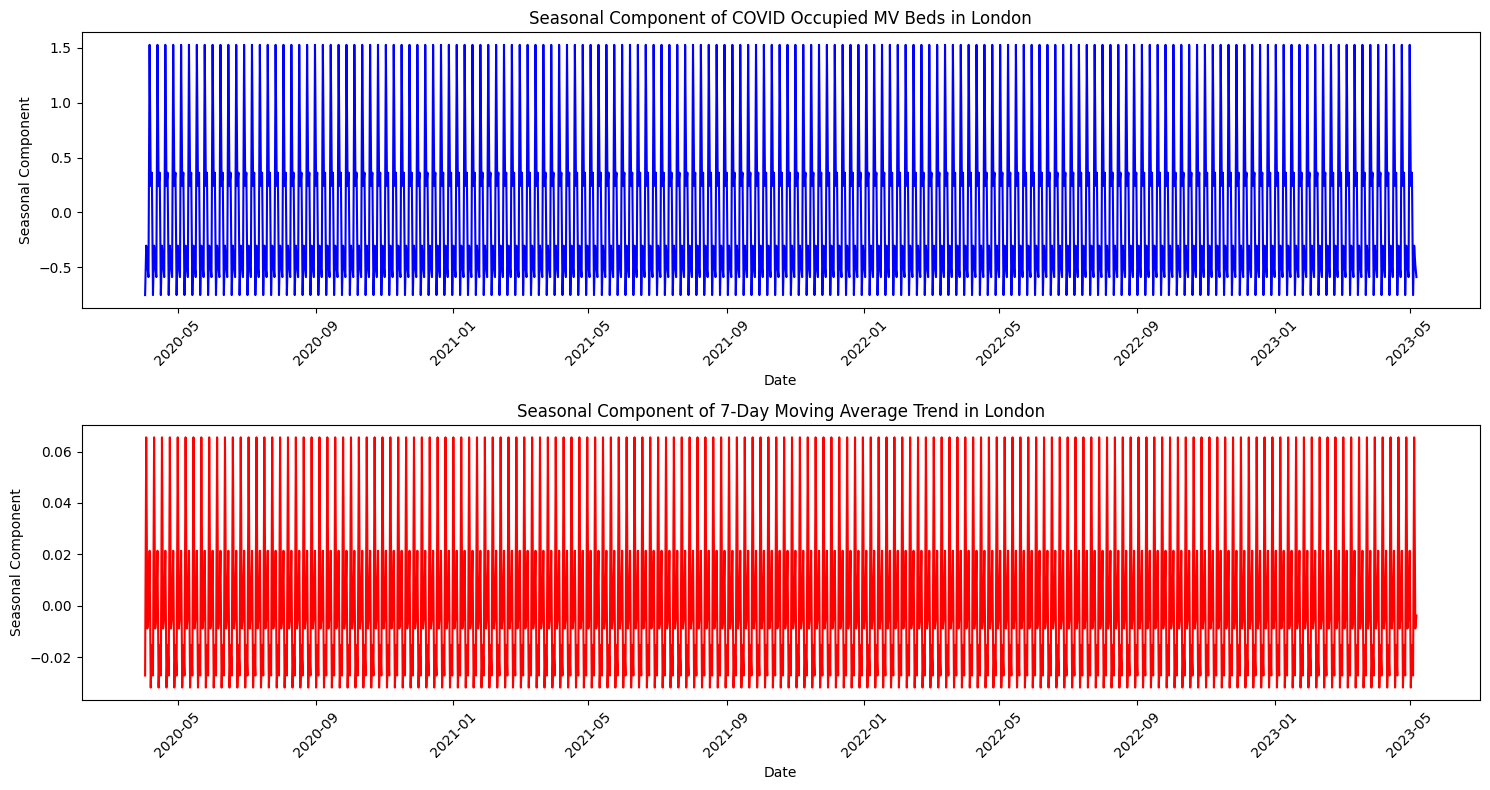

(0.044230497857660867, 0.005275440316995777)

In [21]:
# Decompose the covidOccupiedMVBeds data for London
original_decomposition = seasonal_decompose(data_lon.set_index('date')['covidOccupiedMVBeds'], model='additive', period=7)
trend_decomposition = seasonal_decompose(data_lon.set_index('date')['covidOccupiedMVBeds_trend'], model='additive', period=7)

# Plot the seasonal component for both columns
fig, ax = plt.subplots(2, 1, figsize=(15, 8))

# Seasonal component for original data
ax[0].plot(original_decomposition.seasonal, label='Original Data Seasonal Component', color='blue')
ax[0].set_title('Seasonal Component of COVID Occupied MV Beds in London')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Seasonal Component')
ax[0].tick_params(axis='x', rotation=45)

# Seasonal component for trend data
ax[1].plot(trend_decomposition.seasonal, label='7-Day Moving Average Trend Seasonal Component', color='red')
ax[1].set_title('Seasonal Component of 7-Day Moving Average Trend in London')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Seasonal Component')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Augmented Dickey-Fuller test for stationarity
original_adf_result = adfuller(data_lon['covidOccupiedMVBeds'])
trend_adf_result = adfuller(data_lon['covidOccupiedMVBeds_trend'])

original_adf_result[1], trend_adf_result[1]

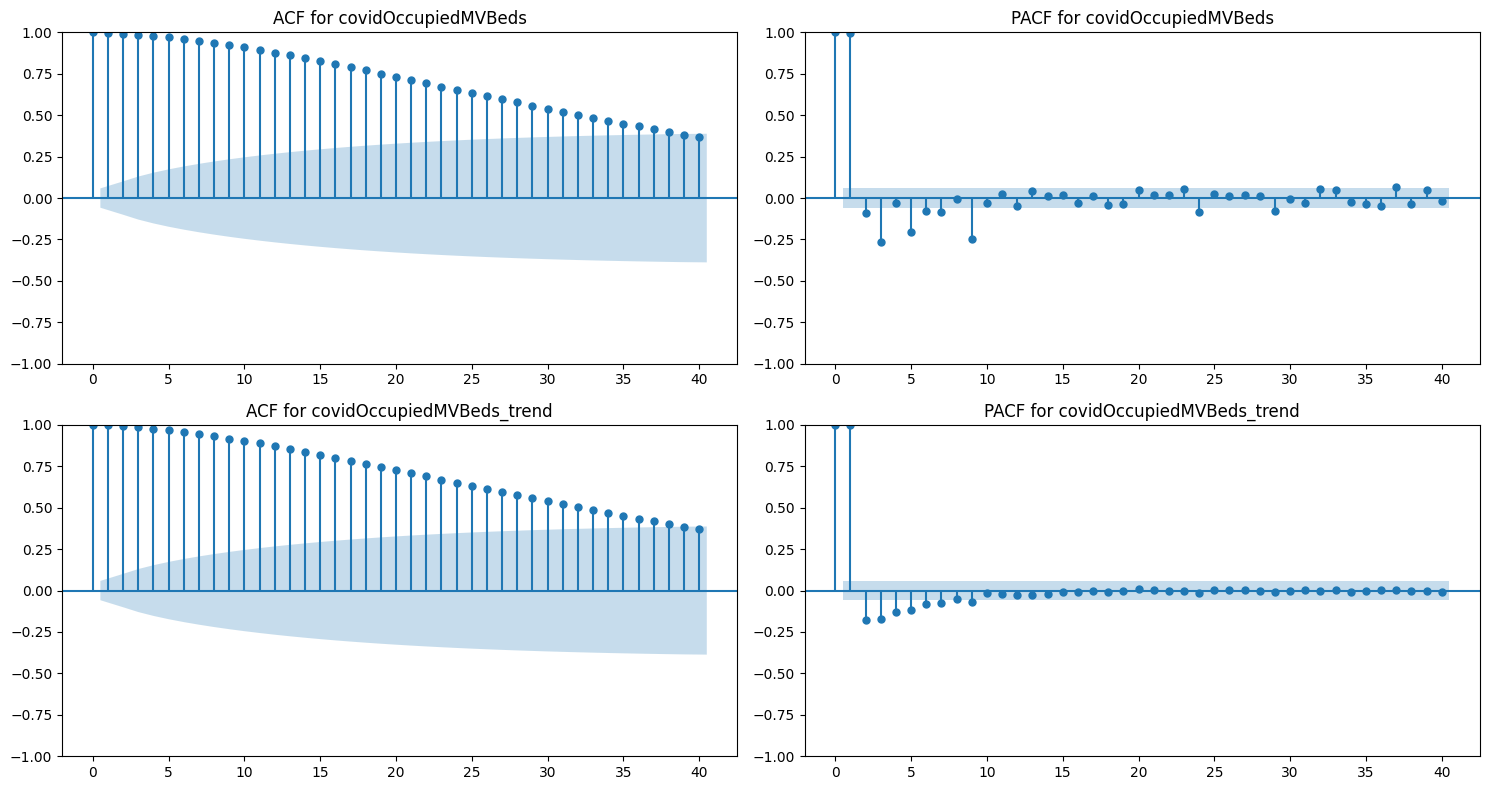

In [22]:
fig, ax = plt.subplots(2, 2, figsize=(15, 8))
# ACF and PACF for covidOccupiedMVBeds
plot_acf(data_lon['covidOccupiedMVBeds'], lags=40, ax=ax[0, 0], title='ACF for covidOccupiedMVBeds')
plot_pacf(data_lon['covidOccupiedMVBeds'], lags=40, ax=ax[0, 1], title='PACF for covidOccupiedMVBeds')

# ACF and PACF for covidOccupiedMVBeds_trend
plot_acf(data_lon['covidOccupiedMVBeds_trend'], lags=40, ax=ax[1, 0], title='ACF for covidOccupiedMVBeds_trend')
plot_pacf(data_lon['covidOccupiedMVBeds_trend'], lags=40, ax=ax[1, 1], title='PACF for covidOccupiedMVBeds_trend')

plt.tight_layout()
plt.show()

In [23]:
def apply_differencing(data):
    """
    Apply differencing transformations to the dataset.
    
    Parameters:
    - data: DataFrame containing the dataset
    
    Returns:
    - DataFrame with differenced columns and NaN rows dropped
    """
    data['date'] = pd.to_datetime(data['date'])
    # Apply first differencing
    data['covidOccupiedMVBeds_trend_diff'] = data.groupby('areaName')['covidOccupiedMVBeds_trend'].diff()

    # Apply seasonal differencing (7-day lag)
    data['covidOccupiedMVBeds_trend_seasonal_diff'] = data.groupby('areaName')['covidOccupiedMVBeds_trend'].diff(7)

    # Drop rows with NaN values
    return data.dropna(inplace=True)

In [24]:
data_transformed = apply_differencing(final_data)

In [25]:
final_data.head()

,areaCode,areaName,areaType,date,covidOccupiedMVBeds,cumAdmissions,hospitalCases,newAdmissions,covidOccupiedMVBeds_trend,cumAdmissions_trend,hospitalCases_trend,newAdmissions_trend,covidOccupiedMVBeds_trend_diff,covidOccupiedMVBeds_trend_seasonal_diff
13,E40000007,East of England,nhsRegion,2023-05-18,10,104828,367,35,7.714286,104952.428571,340.428571,42.142857,0.571429,2.142857
14,E40000007,East of England,nhsRegion,2023-05-17,8,104793,393,54,7.857143,104910.285714,351.142857,43.571429,0.142857,2.000000
15,E40000007,East of England,nhsRegion,2023-05-16,5,104739,371,50,7.571429,104866.714286,359.428571,44.571429,-0.285714,1.142857
16,E40000007,East of England,nhsRegion,2023-05-15,6,104689,352,59,7.142857,104822.142857,361.857143,44.428571,-0.428571,0.000000
17,E40000007,East of England,nhsRegion,2023-05-14,7,104630,354,49,7.142857,104777.714286,364.285714,45.571429,0.000000,-0.142857


### Time Delay embedding


In [26]:
class LogTime():
    from time import time
    
    def __enter__(self):
        self.start_time = self.time()
        print("Starting operation...")
        
    def __exit__(self, type, value, traceback):
        elapsed_time = self.time() - self.start_time
        print(f"Operation completed in {elapsed_time} seconds.")

def add_lags(df, lags, column, area_name_col):
    added_features = []
    final_df = pd.DataFrame()
    for area_name in df[area_name_col].unique():
        area_df = df[df[area_name_col] == area_name].copy()
        for lag in lags:
            lag_col_name = f"{column}_lag_{lag}"
            area_df[lag_col_name] = area_df[column].shift(lag)
            added_features.append(lag_col_name)
        final_df = pd.concat([final_df, area_df])
        # Drop rows with NaN values
    final_df.dropna(inplace=True)
    return final_df, added_features



In [27]:
lags = (
    1,7,14,21
)
column_to_lag = "covidOccupiedMVBeds"
area_name_col = "areaName"

with LogTime():
    final_data, added_features = add_lags(final_data, lags=lags, column=column_to_lag, area_name_col=area_name_col)

print(f"Features Created: {','.join(added_features)}")

Starting operation...
Operation completed in 0.05381512641906738 seconds.
Features Created: covidOccupiedMVBeds_lag_1,covidOccupiedMVBeds_lag_7,covidOccupiedMVBeds_lag_14,covidOccupiedMVBeds_lag_21,covidOccupiedMVBeds_lag_1,covidOccupiedMVBeds_lag_7,covidOccupiedMVBeds_lag_14,covidOccupiedMVBeds_lag_21,covidOccupiedMVBeds_lag_1,covidOccupiedMVBeds_lag_7,covidOccupiedMVBeds_lag_14,covidOccupiedMVBeds_lag_21,covidOccupiedMVBeds_lag_1,covidOccupiedMVBeds_lag_7,covidOccupiedMVBeds_lag_14,covidOccupiedMVBeds_lag_21,covidOccupiedMVBeds_lag_1,covidOccupiedMVBeds_lag_7,covidOccupiedMVBeds_lag_14,covidOccupiedMVBeds_lag_21,covidOccupiedMVBeds_lag_1,covidOccupiedMVBeds_lag_7,covidOccupiedMVBeds_lag_14,covidOccupiedMVBeds_lag_21,covidOccupiedMVBeds_lag_1,covidOccupiedMVBeds_lag_7,covidOccupiedMVBeds_lag_14,covidOccupiedMVBeds_lag_21


In [28]:
final_data.columns

Index(['areaCode', 'areaName', 'areaType', 'date', 'covidOccupiedMVBeds',
       'cumAdmissions', 'hospitalCases', 'newAdmissions',
       'covidOccupiedMVBeds_trend', 'cumAdmissions_trend',
       'hospitalCases_trend', 'newAdmissions_trend',
       'covidOccupiedMVBeds_trend_diff',
       'covidOccupiedMVBeds_trend_seasonal_diff', 'covidOccupiedMVBeds_lag_1',
       'covidOccupiedMVBeds_lag_7', 'covidOccupiedMVBeds_lag_14',
       'covidOccupiedMVBeds_lag_21'],
      dtype='object')

In [29]:
def add_rolling_features(df, window_size, column, area_name_col=None, agg_funcs=['mean']):
    added_features = []
    if area_name_col:
        final_df = pd.DataFrame()
        for area_name in df[area_name_col].unique():
            area_df = df[df[area_name_col] == area_name].copy()
            for func in agg_funcs:
                roll_col_name = f"{column}_rolling_{window_size}_{func}"
                area_df[roll_col_name] = area_df[column].rolling(window_size).agg(func)
                added_features.append(roll_col_name)
            final_df = pd.concat([final_df, area_df])
        # Drop rows with NaN values
        final_df.dropna(inplace=True)
        return final_df, added_features
    else:
        for func in agg_funcs:
            roll_col_name = f"{column}_rolling_{window_size}_{func}"
            df[roll_col_name] = df[column].rolling(window_size).agg(func)
            added_features.append(roll_col_name)
        # Drop rows with NaN values
        df.dropna(inplace=True)
        return df, added_features


In [30]:
window_size = 7
column_to_roll = "covidOccupiedMVBeds"
area_name_col = "areaName"
agg_funcs = ['mean', 'std']

with LogTime():
    final_data, added_features = add_rolling_features(final_data, window_size=window_size, column=column_to_roll, area_name_col=area_name_col, agg_funcs=agg_funcs)

print(f"Rolling Window Features Created: {','.join(added_features)}")


Starting operation...
Operation completed in 0.04147791862487793 seconds.
Rolling Window Features Created: covidOccupiedMVBeds_rolling_7_mean,covidOccupiedMVBeds_rolling_7_std,covidOccupiedMVBeds_rolling_7_mean,covidOccupiedMVBeds_rolling_7_std,covidOccupiedMVBeds_rolling_7_mean,covidOccupiedMVBeds_rolling_7_std,covidOccupiedMVBeds_rolling_7_mean,covidOccupiedMVBeds_rolling_7_std,covidOccupiedMVBeds_rolling_7_mean,covidOccupiedMVBeds_rolling_7_std,covidOccupiedMVBeds_rolling_7_mean,covidOccupiedMVBeds_rolling_7_std,covidOccupiedMVBeds_rolling_7_mean,covidOccupiedMVBeds_rolling_7_std


In [31]:
def add_temporal_features(df, field_name, area_name_col):
    added_features = []
    final_df = pd.DataFrame()
    for area_name in df[area_name_col].unique():
        area_df = df[df[area_name_col] == area_name].copy()
        area_df[field_name] = pd.to_datetime(area_df[field_name])
        area_df['day_of_week'] = area_df[field_name].dt.dayofweek
        area_df['week_of_year'] = area_df[field_name].dt.isocalendar().week  
        area_df["Month"] = area_df[field_name].dt.month
        area_df["Quarter"] = area_df[field_name].dt.quarter
        added_features.extend(['day_of_week', 'week_of_year', 'Month', 'Quarter'])
        final_df = pd.concat([final_df, area_df])

    return final_df, added_features

# Assuming final_data is your DataFrame and the timestamp field is named 'date'
field_name = "date"
area_name_col = "areaName"

with LogTime():
    final_data, added_features = add_temporal_features(final_data, field_name=field_name, area_name_col=area_name_col)

print(f"Features Created: {','.join(added_features)}")


Starting operation...
Operation completed in 0.05946540832519531 seconds.
Features Created: day_of_week,week_of_year,Month,Quarter,day_of_week,week_of_year,Month,Quarter,day_of_week,week_of_year,Month,Quarter,day_of_week,week_of_year,Month,Quarter,day_of_week,week_of_year,Month,Quarter,day_of_week,week_of_year,Month,Quarter,day_of_week,week_of_year,Month,Quarter


In [32]:
final_data.columns

Index(['areaCode', 'areaName', 'areaType', 'date', 'covidOccupiedMVBeds',
       'cumAdmissions', 'hospitalCases', 'newAdmissions',
       'covidOccupiedMVBeds_trend', 'cumAdmissions_trend',
       'hospitalCases_trend', 'newAdmissions_trend',
       'covidOccupiedMVBeds_trend_diff',
       'covidOccupiedMVBeds_trend_seasonal_diff', 'covidOccupiedMVBeds_lag_1',
       'covidOccupiedMVBeds_lag_7', 'covidOccupiedMVBeds_lag_14',
       'covidOccupiedMVBeds_lag_21', 'covidOccupiedMVBeds_rolling_7_mean',
       'covidOccupiedMVBeds_rolling_7_std', 'day_of_week', 'week_of_year',
       'Month', 'Quarter'],
      dtype='object')

In [33]:
final_data.head()

,areaCode,areaName,areaType,date,covidOccupiedMVBeds,cumAdmissions,hospitalCases,newAdmissions,covidOccupiedMVBeds_trend,cumAdmissions_trend,...,covidOccupiedMVBeds_lag_1,covidOccupiedMVBeds_lag_7,covidOccupiedMVBeds_lag_14,covidOccupiedMVBeds_lag_21,covidOccupiedMVBeds_rolling_7_mean,covidOccupiedMVBeds_rolling_7_std,day_of_week,week_of_year,Month,Quarter
40,E40000007,East of England,nhsRegion,2023-04-21,6,103561,484,45,6.000000,103704.571429,...,5.0,6.0,2.0,10.0,6.000000,0.57735,4,16,4,2
41,E40000007,East of England,nhsRegion,2023-04-20,8,103516,511,52,6.285714,103659.000000,...,6.0,6.0,4.0,10.0,6.285714,0.95119,3,16,4,2
42,E40000007,East of England,nhsRegion,2023-04-19,7,103464,505,58,6.428571,103612.714286,...,8.0,6.0,5.0,10.0,6.428571,0.97590,2,16,4,2
43,E40000007,East of England,nhsRegion,2023-04-18,7,103406,473,48,6.571429,103564.000000,...,7.0,6.0,5.0,9.0,6.571429,0.97590,1,16,4,2
44,E40000007,East of England,nhsRegion,2023-04-17,7,103358,479,97,6.714286,103512.857143,...,7.0,6.0,6.0,5.0,6.714286,0.95119,0,16,4,2


In [34]:
final_data.to_csv('data/NHS_region/Timeseries/final_preprocessed_data.csv')

In [35]:
# Find the minimum and maximum dates
min_date = final_data['date'].min()
max_date = final_data['date'].max()

print("Minimum Date:", min_date)
print("Maximum Date:", max_date)

Minimum Date: 2020-04-02 00:00:00
Maximum Date: 2023-04-21 00:00:00


In [36]:
# Calculate the date ranges for train, val, and test sets
date_range = max_date - min_date
train_end = min_date + pd.Timedelta(days=date_range.days * 0.72)
val_end = train_end + pd.Timedelta(days=date_range.days * 0.13)

# Split the data into train, validation, and test sets based on the date ranges
train = final_data[final_data['date'] < train_end]
val = final_data[(final_data['date'] >= train_end) & (final_data['date'] < val_end)]
test = final_data[final_data['date'] >= val_end]


# Calculate the percentage of dates in each dataset
total_samples = len(data)
train_percentage = len(train) / total_samples * 100
val_percentage = len(val) / total_samples * 100
test_percentage = len(test) / total_samples * 100

print(f"# of Training samples: {len(train)} | # of Validation samples: {len(val)} | # of Test samples: {len(test)}")
print(f"Percentage of Dates in Train: {train_percentage:.2f}% | Percentage of Dates in Validation: {val_percentage:.2f}% | Percentage of Dates in Test: {test_percentage:.2f}%")
print(f"Max Date in Train: {train.date.max()} | Min Date in Validation: {val.date.min()} | Min Date in Test: {test.date.min()}")

# of Training samples: 5621 | # of Validation samples: 1008 | # of Test samples: 1176
Percentage of Dates in Train: 69.52% | Percentage of Dates in Validation: 12.47% | Percentage of Dates in Test: 14.55%
Max Date in Train: 2022-06-13 00:00:00 | Min Date in Validation: 2022-06-14 00:00:00 | Min Date in Test: 2022-11-05 00:00:00


In [37]:
counts = test.groupby('areaName').count().reset_index()

print(counts)

                   areaName  areaCode  areaType  date  covidOccupiedMVBeds  \
0           East of England       168       168   168                  168   
1                    London       168       168   168                  168   
2                  Midlands       168       168   168                  168   
3  North East and Yorkshire       168       168   168                  168   
4                North West       168       168   168                  168   
5                South East       168       168   168                  168   
6                South West       168       168   168                  168   

   cumAdmissions  hospitalCases  newAdmissions  covidOccupiedMVBeds_trend  \
0            168            168            168                        168   
1            168            168            168                        168   
2            168            168            168                        168   
3            168            168            168                     

In [38]:
train.to_csv("data/NHS_region/Timeseries/featured_eng_train.csv")
val.to_csv("data/NHS_region/Timeseries/featured_eng_val.csv")
test.to_csv("data/NHS_region/Timeseries/featured_eng_test.csv")